In [173]:
import os
import sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.image as mpimg
import math
import re
import yaml

In [174]:
# Determine the absolute path to the src directory (one level up from notebooks)
module_path = os.path.abspath(os.path.join("..", "src"))
if module_path not in sys.path:
    sys.path.append(module_path)
import plotting
import utils

In [175]:
ROOT_FOLDER = os.path.dirname(os.getcwd())
RUNS_FOLDER = os.path.join(ROOT_FOLDER, "runs")
SINGLE_RUNS_FOLDER = os.path.join(RUNS_FOLDER, "single_runs")
BATCH_RUNS_FOLDER = os.path.join(RUNS_FOLDER, "batch_runs")
DATA_FOLDER = os.path.join(ROOT_FOLDER, "data")
PROCESSED_DATA_FOLDER = os.path.join(DATA_FOLDER, "processed")
CONFIGS_FOLDER = os.path.join(ROOT_FOLDER, "configs")
MODEL_CONFIGS_FOLDER = os.path.join(CONFIGS_FOLDER, "models")

In [ ]:
# Load data used for modeling and the results of the model
data_folder_name = "elec_s_37_ES_PT_no_bat_limit"
run_results_folder_name = "Apr11_Fri_h11-GTSEP_v1a_multi-37_ES_PT"

In [177]:
# Paths
run_results_folder = os.path.join(SINGLE_RUNS_FOLDER, run_results_folder_name)
model_info_path = os.path.join(run_results_folder, "model_info")
decision_variables_path = os.path.join(run_results_folder, "decision_variables")
dual_variables_path = os.path.join(run_results_folder, "dual_variables")
model_config_path = os.path.join(model_info_path, "config.yaml")

## Read input data

In [178]:
with open(model_config_path, "r") as file:
    model_config = yaml.safe_load(file)
data_folder_name = model_config["data_folder_name"]
VOLL = model_config["VOLL"]
CC = model_config["CC"]
CO2_price = model_config["CO2_price"]
E_limit = model_config["E_limit"]
expansion_factor = model_config["expansion_factor"]
MS = model_config["MS"]
years = model_config["years"]
years = model_config["years"]
representative_period_unit = model_config["representative_period_unit"]
representative_periods = model_config["representative_periods"]
p_max_new_branch = model_config["p_max_new_branch"]
week_weights = model_config["week_weights"]
data_folder = os.path.join(PROCESSED_DATA_FOLDER, data_folder_name)
if representative_period_unit == "week":
    weeks = representative_periods
else:
    print("Error: representative_period_units must be 'week'")

In [179]:
model_config

{'CC': 100,
 'CO2_price': 85,
 'E_limit': inf,
 'MIPGap': 0.01,
 'MS': 0.1,
 'VOLL': 6350,
 'carriers': ['CCGT', 'solar', 'onwind'],
 'clustering_periods': None,
 'clustering_unit': None,
 'data_folder_name': 'elec_s_37_ES_PT_no_bat_limit',
 'discount_rate': 0.07,
 'expansion_factor': 2.0,
 'model_id': '37_ES_PT',
 'model_name': 'GTSEP_v1a_multi',
 'p_max_new_branch': 5000,
 'p_min_new_branch': 100,
 'query': 'not (x > 2 and y < 40)',
 'representative_period_unit': 'week',
 'representative_periods': [21, 42],
 'run_id': 'Apr11_Fri_h11-GTSEP_v1a_multi-37_ES_PT',
 'save_folder': 'C:\\Users\\tinus\\OneDrive\\Dokumenter\\0 Master\\code\\master_project\\runs\\single_runs\\Apr11_Fri_h11-GTSEP_v1a_multi-37_ES_PT',
 'week_weights': {21: 26.071428571428573, 42: 26.071428571428573},
 'years': [2025, 2035, 2045]}

In [180]:
input_data = utils.load_multi_year_csv_files_with_week_from_folder(
    years, weeks, data_folder
)
input_data.keys()

dict_keys(['batteries', 'branches', 'capacity_factors', 'generators', 'generator_costs', 'hourly_demand', 'nodes'])

In [181]:
batteries = input_data["batteries"]
branches = input_data["branches"]
capacity_factors = input_data["capacity_factors"]
generators = input_data["generators"]
generator_costs = input_data["generator_costs"]
hourly_demand = input_data["hourly_demand"]
nodes = input_data["nodes"]

In [182]:
generators

bus     carrier         p_nom  marginal_cost  \
year generator                                                          
2025 ES1 0 CCGT        ES1 0        CCGT  26305.332000      40.772380   
     ES1 0 coal        ES1 0        coal   4739.393483      28.196970   
     ES1 0 offwind-ac  ES1 0  offwind-ac   9274.463486       0.015000   
     ES1 0 onwind      ES1 0      onwind  26825.862669       0.015000   
     ES1 0 ror         ES1 0         ror    147.008247       0.000000   
     ES1 0 solar       ES1 0       solar  11681.579273       0.010000   
     PT1 0 CCGT        PT1 0        CCGT   4145.000000      38.876697   
     PT1 0 offwind-ac  PT1 0  offwind-ac   4460.188736       0.015000   
     PT1 0 onwind      PT1 0      onwind   5213.640675       0.015000   
     PT1 0 ror         PT1 0         ror   2638.500000       0.000000   
     PT1 0 solar       PT1 0       solar   1025.440000       0.010000   
2035 ES1 0 CCGT        ES1 0        CCGT  26305.332000      40.772380   
     ES1 0 coal        ES1 0        coal   4739.393483      28.196970   
     ES1 0 offwind-ac  ES1 0  offwind-ac   9274.463486       0.015000   
     ES1 0 onwind      ES1 0      onwind  26825.862669       0.015000   
     ES1 0 ror         ES1 0         ror    147.008247       0.000000   
     ES1 0 solar       ES1 0       solar  11681.579273       0.010000   
     PT1 0 CCGT        PT1 0        CCGT   4145.000000      38.876697   
     PT1 0 offwind-ac  PT1 0  offwind-ac   4460.188736       0.015000   
     PT1 0 onwind      PT1 0      onwind   5213.640675       0.015000   
     PT1 0 ror         PT1 0         ror   2638.500000       0.000000   
     PT1 0 solar       PT1 0       solar   1025.440000       0.010000   
2045 ES1 0 CCGT        ES1 0        CCGT  26305.332000      40.772380   
     ES1 0 coal        ES1 0        coal   4739.393483      28.196970   
     ES1 0 offwind-ac  ES1 0  offwind-ac   9274.463486       0.015000   
     ES1 0 onwind      ES1 0      onwind  26825.862669       0.015000   
     ES1 0 ror         ES1 0         ror    147.008247       0.000000   
     ES1 0 solar       ES1 0       solar  11681.579273       0.010000   
     PT1 0 CCGT        PT1 0        CCGT   4145.000000      38.876697   
     PT1 0 offwind-ac  PT1 0  offwind-ac   4460.188736       0.015000   
     PT1 0 onwind      PT1 0      onwind   5213.640675       0.015000   
     PT1 0 ror         PT1 0         ror   2638.500000       0.000000   
     PT1 0 solar       PT1 0       solar   1025.440000       0.010000   

                        capital_cost  co2_emissions    color  \
year generator                                                 
2025 ES1 0 CCGT         99027.729293           0.20  #b20101   
     ES1 0 coal        349976.553630           0.34  #707070   
     ES1 0 offwind-ac  184160.119456           0.00  #6895dd   
     ES1 0 onwind       96085.888020           0.00  #235ebc   
     ES1 0 ror         299140.224929           0.00  #4adbc8   
     ES1 0 solar        35602.071244           0.00  #f9d002   
     PT1 0 CCGT         99027.729293           0.20  #b20101   
     PT1 0 offwind-ac  185034.009941           0.00  #6895dd   
     PT1 0 onwind       96085.888020           0.00  #235ebc   
     PT1 0 ror         299140.224929           0.00  #4adbc8   
     PT1 0 solar        35602.071244           0.00  #f9d002   
2035 ES1 0 CCGT         99027.729293           0.20  #b20101   
     ES1 0 coal        349976.553630           0.34  #707070   
     ES1 0 offwind-ac  184160.119456           0.00  #6895dd   
     ES1 0 onwind       96085.888020           0.00  #235ebc   
     ES1 0 ror         299140.224929           0.00  #4adbc8   
     ES1 0 solar        35602.071244           0.00  #f9d002   
     PT1 0 CCGT         99027.729293           0.20  #b20101   
     PT1 0 offwind-ac  185034.009941           0.00  #6895dd   
     PT1 0 onwind       96085.888020           0.00  #235ebc   
     PT1 0 ror         299140.224929           0.00  #4adbc8 

In [183]:
branches.index.rename({"line": "branch"}, inplace=True)

In [184]:
decision_variables = utils.load_csv_files_from_folder_multi_weeks(
    decision_variables_path
)
battery_capacity = decision_variables["battery_capacity"]
battery_charging = decision_variables["battery_charging"]
battery_discharging = decision_variables["battery_discharging"]
battery_soc = decision_variables["battery_soc"]
branch_capacity = decision_variables["branch_capacity"]
curtailment = decision_variables["curtailment"]
generation = decision_variables["generation"]
generator_capacity = decision_variables["generator_capacity"]
load_shedding = decision_variables["load_shedding"]
power_flow = decision_variables["power_flow"]

In [185]:
# Update generators with new capacity values with investments
gen_ext = generator_capacity.copy()
gen_ext = gen_ext.reindex(generators.index, fill_value=0)

# Step 2: Add 'extended_by' column
generators["extended_by"] = gen_ext["value"]

# Step 3: Calculate cumulative extension for each generator across years
generators = generators.sort_index()  # sort by year and generator
generators["extended_by_cum"] = generators.groupby("generator")["extended_by"].cumsum()

# Step 4: Add total capacity = p_nom + extended_by_cum
generators["total_capacity"] = generators["p_nom"] + generators["extended_by_cum"]

In [186]:
# Set extenstion potential for branches and generators
branches["extension_potential"] = p_max_new_branch * branches["extendable"]
generators["extension_potential"] = (
    generators["p_nom"] * generators["extendable"] * expansion_factor
)

In [187]:
# Step 1: Copy and align battery_capacity with batteries index
battery_ext = battery_capacity.copy()
battery_ext = battery_ext.reindex(batteries.index, fill_value=0)

# Step 2: Add extension for energy capacity (MWh)
batteries["extended_by_soc"] = battery_ext["value"]  # MWh

# Step 3: Add extension for power capacity (MW)
batteries["extended_by_p"] = (
    batteries["extended_by_soc"] / batteries["hour_capacity"]
)  # MW

# Step 4: Cumulative sums over years (grouped by battery ID)
batteries = batteries.sort_index()
batteries["extended_by_soc_cum"] = batteries.groupby("battery")[
    "extended_by_soc"
].cumsum()
batteries["extended_by_p_cum"] = batteries.groupby("battery")["extended_by_p"].cumsum()

# Step 5: Set total capacity fields
batteries["total_energy_capacity"] = batteries["extended_by_soc_cum"]  # MWh
batteries["total_power_capacity"] = batteries["extended_by_p_cum"]  # MW

In [188]:
# Update branches with new capacity values with investments


# Step 1: Ensure 'branches' and 'branch_capacity' are aligned on MultiIndex ["year", "branch"]
branch_ext = branch_capacity.copy()
branch_ext = branch_ext.reindex(branches.index, fill_value=0)

# Step 2: Add 'extended_by' from the decision variable
branches["extended_by"] = branch_ext["value"]

# Step 3: Calculate cumulative extension by branch
branches = branches.sort_index()
branches["extended_by_cum"] = branches.groupby("branch")["extended_by"].cumsum()

# Step 4: Add total capacity = p_max + cumulative additions
branches["total_capacity"] = branches["p_max"] + branches["extended_by_cum"]

In [189]:
def inspect_dataframes_structure(data: dict[str, pd.DataFrame], n: int = 3) -> None:
    """
    Print a structural summary of each dataframe in a dictionary:
    - Name
    - Index names
    - Column names
    - First n rows
    """
    for name, df in data.items():
        print(f"\n📄 DataFrame: {name}")
        print(f"Index names: {df.index.names}")
        print(f"Column names: {list(df.columns)}")
        print("First few rows:")
        print(df.head(n))

In [190]:
# inspect_dataframes_structure(input_data)

In [191]:
dual_variables = utils.load_csv_files_from_folder_multi_weeks(dual_variables_path)

In [192]:
emissions_dual = dual_variables["emissions_dual"]
gen_output_new_duals = dual_variables["gen_output_new_duals"]
gen_output_old_duals = dual_variables["gen_output_old_duals"]
load_shedding_duals = dual_variables["load_shedding_duals"]
power_balance_duals = dual_variables["power_balance_duals"]

In [193]:
# inspect_dataframes_structure(dual_variables)

In [194]:
# Flip sign to get shadow prices (economic value of more generation)
gen_output_new_duals["shadow_price"] = -gen_output_new_duals["dual_value"]

# Filter for binding constraints (positive shadow price)
binding_duals = gen_output_new_duals[gen_output_new_duals["shadow_price"] > 1e-5]

# Group by generator: compute mean, max, and count of binding hours
constrained_stats = (
    binding_duals.groupby("generator")["shadow_price"]
    .agg(["mean", "max", "count"])
    .rename(columns={"count": "binding_hours"})
)

# Add total hours per generator from the full dataset
total_hours = gen_output_new_duals.index.get_level_values("generator").value_counts()
constrained_stats["total_hours"] = constrained_stats.index.map(total_hours)

# Calculate how often each generator is constrained
constrained_stats["binding_ratio"] = (
    constrained_stats["binding_hours"] / constrained_stats["total_hours"]
)

# Sort by mean shadow price (most valuable constraints)
constrained_stats = constrained_stats.sort_values(by="mean", ascending=False)

In [195]:
constrained_stats

,mean,max,binding_hours,total_hours,binding_ratio
generator,,,,,
ES1 0 CCGT,292.178759,1048.655902,13,1008,0.012897
ES1 0 offwind-ac,61.209263,1106.413283,827,1008,0.820437
ES1 0 onwind,61.209263,1106.413283,827,1008,0.820437
PT1 0 offwind-ac,50.516150,1107.532785,1002,1008,0.994048
PT1 0 onwind,50.516150,1107.532785,1002,1008,0.994048
ES1 0 ror,50.233312,1106.428283,1008,1008,1.000000
PT1 0 ror,50.230459,1107.547785,1008,1008,1.000000
ES1 0 solar,50.223312,1106.418283,1008,1008,1.000000
PT1 0 solar,50.220459,1107.537785,1008,1008,1.000000


In [196]:
high_duals = gen_output_new_duals[gen_output_new_duals["shadow_price"] > 1000].copy()
high_duals = high_duals.reset_index().sort_values(by="shadow_price", ascending=False)
print("High dual entries (shadow_price > 9000):")
high_duals

High dual entries (shadow_price > 9000):


,year,week,hour,generator,dual_value,shadow_price
29,2045,42,91,PT1 0 ror,-1107.547785,1107.547785
28,2045,42,90,PT1 0 ror,-1107.547785,1107.547785
27,2045,42,89,PT1 0 ror,-1107.547785,1107.547785
32,2045,42,91,PT1 0 solar,-1107.537785,1107.537785
31,2045,42,90,PT1 0 solar,-1107.537785,1107.537785
30,2045,42,89,PT1 0 solar,-1107.537785,1107.537785
26,2045,42,91,PT1 0 onwind,-1107.532785,1107.532785
25,2045,42,90,PT1 0 onwind,-1107.532785,1107.532785
24,2045,42,89,PT1 0 onwind,-1107.532785,1107.532785
23,2045,42,91,PT1 0 offwind-ac,-1107.532785,1107.532785


In [197]:
merged = high_duals.merge(
    load_shedding.reset_index(),
    on=["year", "week", "hour"],
    how="left",
    suffixes=("", "_load_shed"),
)

# See if any load was shed at these high-dual hours
print("\nLoad shedding in high-dual hours:")
print(merged[merged["value"] > 1e-3].sort_values("shadow_price", ascending=False))


Load shedding in high-dual hours:
Empty DataFrame
Columns: [year, week, hour, generator, dual_value, shadow_price, node, value]
Index: []


In [198]:
# Merge generation with capacity factors
dispatch = generation.reset_index()
cf = capacity_factors.reset_index()
dispatch = dispatch.merge(cf, on=["year", "week", "hour"])

# Get the installed capacity (p_nom) from the generators dataframe
dispatch["total_capacity"] = dispatch.apply(
    lambda row: (
        generators.loc[(row["year"], row["generator"]), "total_capacity"]
        if (row["year"], row["generator"]) in generators.index
        else None
    ),
    axis=1,
)

# Get the correct column name from capacity_factors: it's dynamic, e.g. "PT1 0 solar"
# Use the row's generator as a column name to extract the capacity factor
dispatch["cf"] = dispatch.apply(lambda row: row.get(row["generator"], None), axis=1)

# Calculate the theoretical output cap
dispatch["dispatch_limit"] = dispatch["total_capacity"] * dispatch["cf"]

# Calculate utilization ratio
dispatch["utilization"] = dispatch["value"] / dispatch["dispatch_limit"]

In [199]:
# Get just year, week, hour combinations of interest
high_hours = high_duals[["year", "week", "hour"]].drop_duplicates()

# Merge to get dispatch in those hours only
dispatch_high = dispatch.merge(high_hours, on=["year", "week", "hour"])

# Look at generators near or at their cap
near_limit = dispatch_high[dispatch_high["utilization"] >= 0.95]

# View summary
with pd.option_context("display.max_rows", None, "display.max_columns", None):
    print("\nGenerators near their limit during high-dual hours:")
    print(
        near_limit[
            [
                "year",
                "week",
                "hour",
                "generator",
                "value",
                "dispatch_limit",
                "utilization",
            ]
        ]
    )


Generators near their limit during high-dual hours:
    year  week  hour         generator         value  dispatch_limit  \
0   2045    42    89        ES1 0 CCGT  58476.920303    58476.920303   
1   2045    42    90        ES1 0 CCGT  58476.920303    58476.920303   
2   2045    42    91        ES1 0 CCGT  58476.920303    58476.920303   
3   2045    42    89        ES1 0 coal   4739.393483     4739.393483   
4   2045    42    90        ES1 0 coal   4739.393483     4739.393483   
5   2045    42    91        ES1 0 coal   4739.393483     4739.393483   
6   2045    42    89  ES1 0 offwind-ac   3065.598445     3065.598445   
7   2045    42    90  ES1 0 offwind-ac   2599.743938     2599.743938   
8   2045    42    91  ES1 0 offwind-ac   2522.652764     2522.652764   
9   2045    42    89      ES1 0 onwind   5404.025773     5404.025773   
10  2045    42    90      ES1 0 onwind   6033.940878     6033.940878   
11  2045    42    91      ES1 0 onwind   6331.169404     6331.169404   
12  2045   

In [200]:
# Extract and drop duplicates
near_limit_timesteps = near_limit[["year", "week", "hour"]].drop_duplicates()

# Reset index for convenience
near_limit_timesteps = near_limit_timesteps.reset_index(drop=True)

# Display result
print("Timesteps when at least one generator was near its limit:")
print(near_limit_timesteps)

Timesteps when at least one generator was near its limit:
   year  week  hour
0  2045    42    89
1  2045    42    90
2  2045    42    91


In [201]:
key_times = set(
    [tuple(x) for x in near_limit_timesteps[["year", "week", "hour"]].values]
)
key_times

{(2045, 42, 89), (2045, 42, 90), (2045, 42, 91)}

In [202]:
# Filter generation
gen_filtered = generation.reset_index()
gen_filtered = gen_filtered[
    gen_filtered[["year", "week", "hour"]].apply(tuple, axis=1).isin(key_times)
]

# Filter capacity factors
cf_filtered = capacity_factors.reset_index()
cf_filtered = cf_filtered[
    cf_filtered[["year", "week", "hour"]].apply(tuple, axis=1).isin(key_times)
]

# Step 2: Merge generation with capacity factors
gen_cf = gen_filtered.merge(cf_filtered, on=["year", "week", "hour"])

# Step 3: Add total_capacity from generators
gen_cf["total_capacity"] = gen_cf.apply(
    lambda row: (
        generators.loc[(row["year"], row["generator"]), "total_capacity"]
        if (row["year"], row["generator"]) in generators.index
        else None
    ),
    axis=1,
)

# Step 4: Add capacity factor (the column name is the generator name)
gen_cf["cf"] = gen_cf.apply(lambda row: row.get(row["generator"], None), axis=1)

# Step 5: Compute dispatch limit
gen_cf["dispatch_limit"] = gen_cf["total_capacity"] * gen_cf["cf"]

# Step 6: Output generation vs dispatch limit
gen_cf["utilization_ratio"] = gen_cf["value"] / gen_cf["dispatch_limit"]

# Optional: clean up and sort
result = gen_cf[
    [
        "year",
        "week",
        "hour",
        "generator",
        "value",
        "dispatch_limit",
        "utilization_ratio",
    ]
]
result = result.sort_values(by=["year", "week", "hour", "generator"]).reset_index(
    drop=True
)

# Display the final result
print("Generation vs theoretical maximum at near-limit timesteps:")
print(result)

Generation vs theoretical maximum at near-limit timesteps:
    year  week  hour         generator         value  dispatch_limit  \
0   2045    42    89        ES1 0 CCGT  58476.920303    58476.920303   
1   2045    42    89        ES1 0 coal   4739.393483     4739.393483   
2   2045    42    89  ES1 0 offwind-ac   3065.598445     3065.598445   
3   2045    42    89      ES1 0 onwind   5404.025773     5404.025773   
4   2045    42    89         ES1 0 ror      7.234849        7.234849   
5   2045    42    89       ES1 0 solar    427.942386      427.942386   
6   2045    42    89        PT1 0 CCGT  29015.000000    29015.000000   
7   2045    42    89  PT1 0 offwind-ac    164.629173      164.629173   
8   2045    42    89      PT1 0 onwind     39.962327       39.962327   
9   2045    42    89         PT1 0 ror    140.743869      140.743869   
10  2045    42    89       PT1 0 solar    206.022422      206.022422   
11  2045    42    90        ES1 0 CCGT  58476.920303    58476.920303   
12  2

In [203]:
# Merge generation duals with load shedding to compare
gen_duals = gen_output_new_duals["dual_value"].reset_index()
gen_duals["shadow_price"] = -gen_duals["dual_value"]

load_shed = load_shedding["value"].reset_index()
merged = pd.merge(gen_duals, load_shed, on=["year", "week", "hour"], how="left")

# Only keep rows where shadow price is near VOLL
threshold = 0.95 * VOLL
high_dual_hours = merged[merged["shadow_price"] >= threshold]

# Display some high-dual entries with load shedding info
print("\nHigh-dual hours and associated load shedding:")
with pd.option_context("display.max_rows", None):
    print(high_dual_hours.sort_values(by="shadow_price", ascending=False))


High-dual hours and associated load shedding:
Empty DataFrame
Columns: [year, week, hour, generator, dual_value, shadow_price, node, value]
Index: []


In [204]:
prev_key_times = set(
    (year, week, hour - 1)
    for year, week, hour in near_limit_timesteps[["year", "week", "hour"]].values
)


print(prev_key_times)

{(2045, 42, 89), (2045, 42, 90), (2045, 42, 88)}


In [205]:
# Step 1: Prepare key times from near_limit_timesteps
key_times = set(tuple(x) for x in near_limit_timesteps[["year", "week", "hour"]].values)

# Step 2: Filter battery SOC and discharge for relevant timesteps
discharge_filtered = battery_discharging.reset_index()
soc_filtered = battery_soc.reset_index()

# Filter for target hours
discharge_filtered = discharge_filtered[
    discharge_filtered[["year", "week", "hour"]].apply(tuple, axis=1).isin(key_times)
]
soc_current = soc_filtered[
    soc_filtered[["year", "week", "hour"]].apply(tuple, axis=1).isin(key_times)
]
prev_key_times = {(year, week, hour - 1) for year, week, hour in key_times}
# Step 3: Compute previous time steps
soc_prev = soc_filtered[
    soc_filtered[["year", "week", "hour"]].apply(tuple, axis=1).isin(prev_key_times)
]


# Rename column for clarity
soc_prev = soc_prev.rename(columns={"value": "value_soc_prev"})
soc_prev["hour"] = soc_prev["hour"] + 1

# Step 4: Merge current SOC with previous SOC
soc_merged = soc_current.merge(
    soc_prev[["year", "week", "hour", "battery", "value_soc_prev"]],
    on=["year", "week", "hour", "battery"],
    how="left",
)

# Step 5: Merge with discharge
battery_status = discharge_filtered.merge(
    soc_merged,
    on=["year", "week", "hour", "battery"],
    how="inner",
    suffixes=("_discharge", "_soc"),
)

# Step 6: Add cumulative capacity info from batteries
battery_status["SOC_max_frac"] = battery_status.apply(
    lambda row: (
        batteries.loc[(row["year"], row["battery"]), "SOC_max"]
        if (row["year"], row["battery"]) in batteries.index
        else None
    ),
    axis=1,
)
battery_status["total_energy_capacity"] = battery_status.apply(
    lambda row: (
        batteries.loc[(row["year"], row["battery"]), "total_energy_capacity"]
        if (row["year"], row["battery"]) in batteries.index
        else None
    ),
    axis=1,
)
battery_status["total_power_capacity"] = battery_status.apply(
    lambda row: (
        batteries.loc[(row["year"], row["battery"]), "total_power_capacity"]
        if (row["year"], row["battery"]) in batteries.index
        else None
    ),
    axis=1,
)

# Step 7: Compute max SOC and ratios
battery_status["SOC_max"] = (
    battery_status["SOC_max_frac"] * battery_status["total_energy_capacity"]
)
battery_status["soc_ratio"] = battery_status["value_soc"] / battery_status["SOC_max"]
battery_status["discharge_ratio"] = (
    battery_status["value_discharge"] / battery_status["total_power_capacity"]
)
battery_status["soc_ratio_prev"] = (
    battery_status["value_soc_prev"] / battery_status["SOC_max"]
)

# Step 8: Final cleaned-up output
battery_usage_summary = (
    battery_status[
        [
            "year",
            "week",
            "hour",
            "battery",
            "value_discharge",
            "total_power_capacity",
            "discharge_ratio",
            "value_soc_prev",
            "value_soc",
            "SOC_max",
            "soc_ratio_prev",
            "soc_ratio",
        ]
    ]
    .sort_values(by=["year", "week", "hour", "battery"])
    .reset_index(drop=True)
)

with pd.option_context("display.max_rows", None, "display.max_columns", None):
    print("Battery usage summary:")
    print(battery_usage_summary)

Battery usage summary:
   year  week  hour    battery  value_discharge  total_power_capacity  \
0  2045    42    89  ES1 0 bat      3012.794171          10851.989803   
1  2045    42    89  PT1 0 bat      5468.988371          12161.424735   
2  2045    42    90  ES1 0 bat      9042.892196          10851.989803   
3  2045    42    90  PT1 0 bat      7235.241791          12161.424735   
4  2045    42    91  ES1 0 bat      4786.601808          10851.989803   
5  2045    42    91  PT1 0 bat      6170.301027          12161.424735   

   discharge_ratio  value_soc_prev     value_soc       SOC_max  \
0         0.277626    19533.581646  16427.608274  19533.581646   
1         0.449700    21890.564524  16252.432182  21890.564524   
2         0.833293    16427.608274   7105.039000  19533.581646   
3         0.594934    16252.432182   8793.420026  21890.564524   
4         0.441081     7105.039000   2170.397961  19533.581646   
5         0.507367     8793.420026   2432.284947  21890.564524   

  

In [206]:
# Step 1: Get the key (year, week, hour) tuples
key_times = set(
    [tuple(x) for x in near_limit_timesteps[["year", "week", "hour"]].values]
)

# Step 2: Filter power_flow for those timesteps
flow_filtered = power_flow.reset_index()
flow_filtered = flow_filtered[
    flow_filtered[["year", "week", "hour"]].apply(tuple, axis=1).isin(key_times)
]

# Step 3: Add total capacity (from branches dataframe)
flow_filtered["total_capacity"] = flow_filtered.apply(
    lambda row: (
        branches.loc[(row["year"], row["branch"]), "total_capacity"]
        if (row["year"], row["branch"]) in branches.index
        else None
    ),
    axis=1,
)

# Step 4: Calculate flow utilization (abs value / capacity)
flow_filtered["abs_flow"] = flow_filtered["value"].abs()
flow_filtered["flow_ratio"] = (
    flow_filtered["abs_flow"] / flow_filtered["total_capacity"]
)

# Step 5: Clean output
flow_summary = (
    flow_filtered[
        ["year", "week", "hour", "branch", "value", "total_capacity", "flow_ratio"]
    ]
    .sort_values(by=["year", "week", "hour", "branch"])
    .reset_index(drop=True)
)

print("Power flow vs max capacity at near-limit timesteps:")
print(flow_summary)

Power flow vs max capacity at near-limit timesteps:
   year  week  hour  branch        value  total_capacity  flow_ratio
0  2045    42    89      35 -16297.22093     16297.22093         1.0
1  2045    42    90      35 -16297.22093     16297.22093         1.0
2  2045    42    91      35 -16297.22093     16297.22093         1.0


## What can be said about the duals for the power generation?

3a\. **Generator output limits (existing generators)**

$$
P_{i}^{\min} \leq g_{i,y,w,t} \leq P_{i}^{\max} cf_{i,y,w,t}, \quad \forall i \in G^{old},y,w,t
$$

3b\. **Generator output limits (new generators)**

$$
0 \leq g_{i,y,w,t} \leq cf_{i,y,w,t}\sum_{y'\in Y_y}p_{i,y'}^{max}, \quad \forall i \in G^{new},y,w,t
$$

Observations:
- The duals are >9000 at some time steps in year 2045. At those times (3 consecutive time steps), there is full utilization of ALL generators capacity, the branches are flowing at max capacity and both batteries are full at the beginning and then is depleted almost fully by the end.
- There is no load shedding at those time steps.

What is causing the price of approximately 9000-10000?  

In [207]:
generator_capacity.loc[2045][generator_capacity.loc[2045]["value"] > 0]

,value
generator,
ES1 0 solar,23363.158546
PT1 0 CCGT,8290.000000
PT1 0 solar,2050.880000


In [208]:
gens = generator_capacity.loc[2045][
    generator_capacity.loc[2045]["value"] > 0
].index.values
generators.loc[2045].loc[gens].sort_values(by="capital_cost", ascending=False)

,bus,carrier,p_nom,marginal_cost,capital_cost,co2_emissions,color,nice_name,extendable,extension_potential,extended_by,extended_by_cum,total_capacity
generator,,,,,,,,,,,,,
PT1 0 CCGT,PT1 0,CCGT,4145.000000,38.876697,99027.729293,0.2,#b20101,Combined-Cycle Gas,True,8290.000000,8290.000000,24870.000000,29015.000000
PT1 0 solar,PT1 0,solar,1025.440000,0.010000,35602.071244,0.0,#f9d002,Solar,True,2050.880000,2050.880000,6152.640000,7178.080000
ES1 0 solar,ES1 0,solar,11681.579273,0.010000,35602.071244,0.0,#f9d002,Solar,True,23363.158546,23363.158546,70089.475638,81771.054911


This shows that CCGT is the next generator to be bought in 2045 since it is the only invested in generator that is not fully utilized. However, the price of investing in another unit of CCGT is over 99000, so it doesn't quite make sense why the price of the dual is around 9000.

## MAYDAY MAYDAY
I figured out what is causing the wierd values. The duals measures the change in objective value. The objective value consists of operational costs which are multiplied by a weighing factor. Therefore, to get the actual price of the dual, I need to divide by the weighing factor. Furthermore, the objective value is divided by the number of years. Therefore, I need to multiply by the number of year to get the actual price. Alternatively, I should just remove the divide by the number of years in the objective function, so I maintain actual values and instead can do the calculation to yearly values in the post-optimization analyzes.

### Frequency diagram of the duals

In [209]:
generators["production_cost"] = (
    generators["marginal_cost"] + generators["co2_emissions"] * CO2_price
)
generators["production_cost"].loc[2025]

generator
ES1 0 CCGT          57.772380
ES1 0 coal          57.096970
ES1 0 offwind-ac     0.015000
ES1 0 onwind         0.015000
ES1 0 ror            0.000000
ES1 0 solar          0.010000
PT1 0 CCGT          55.876697
PT1 0 offwind-ac     0.015000
PT1 0 onwind         0.015000
PT1 0 ror            0.000000
PT1 0 solar          0.010000
Name: production_cost, dtype: float64

In [210]:
import pandas as pd
import numpy as np

# Step 1: Count dual value frequencies
dual_value_counts = (
    gen_output_old_duals["dual_value"]
    .value_counts()
    .rename_axis("dual_value")
    .reset_index(name="frequency")
    .sort_values("dual_value")
)

# Step 2: Round duals for display only (keep original for matching)
dual_value_counts["dual_value_display"] = dual_value_counts["dual_value"].round(3)

# Step 3: Get production costs and corresponding target duals
production_costs = generators["production_cost"].loc[2025].round(5).reset_index()
production_costs.columns = ["generator", "production_cost"]
production_costs["dual_target"] = -production_costs[
    "production_cost"
]  # duals are negative

# Group by unique dual_target
cost_to_generators = (
    production_costs.groupby("dual_target")["generator"].apply(list).reset_index()
)

# Step 4: Fuzzy match function with ±0.01 tolerance
tolerance = 0.01


def match_dual_to_generators(dual_val):
    matches = cost_to_generators[
        np.abs(cost_to_generators["dual_target"] - dual_val) <= tolerance
    ]
    if matches.empty:
        return pd.Series([np.nan, np.nan])
    # If multiple match, combine all
    gens = sum(matches["generator"].tolist(), [])
    if len(gens) > 1:
        gens = ["renewable"]
    return pd.Series([matches["dual_target"].values[0], gens])


# Apply fuzzy matching
dual_value_counts[["matched_production_cost", "matched_generators"]] = (
    dual_value_counts["dual_value"].apply(match_dual_to_generators)
)

# Step 5: Filter only frequencies > 10
filtered_dual_value_counts = dual_value_counts[dual_value_counts["frequency"] > 10]

# Step 6: Final cleaned dataframe
dual_cost_table = filtered_dual_value_counts[
    ["dual_value_display", "frequency", "matched_production_cost", "matched_generators"]
].rename(
    columns={
        "dual_value_display": "dual_value",
        "matched_production_cost": "prod_cost",
        "matched_generators": "generators",
        "frequency": "f",
    }
)

# Display full output
with pd.option_context(
    "display.max_rows", None, "display.max_columns", None, "expand_frame_repr", False
):
    print("Dual values with fuzzy-matched generators (±0.01), frequency > 10:")
    print(dual_cost_table)

Dual values with fuzzy-matched generators (±0.01), frequency > 10:
    dual_value     f  prod_cost    generators
33     -62.639    14        NaN           NaN
34     -60.583    12        NaN           NaN
13     -58.951   184        NaN           NaN
15     -58.941   184        NaN           NaN
9      -58.936   368        NaN           NaN
31     -58.262    29        NaN           NaN
30     -58.252    29        NaN           NaN
27     -58.247    58        NaN           NaN
6      -57.772   463  -57.77238  [ES1 0 CCGT]
7      -57.762   463  -57.77238  [ES1 0 CCGT]
2      -57.757   926        NaN           NaN
24     -57.097    69  -57.09697  [ES1 0 coal]
23     -57.087    69        NaN           NaN
17     -57.082   138        NaN           NaN
4      -55.877   596  -55.87670  [PT1 0 CCGT]
3      -55.867   596        NaN           NaN
1      -55.862  1192        NaN           NaN
11     -54.759   277        NaN           NaN
10     -54.749   277        NaN           NaN
5      -54.74

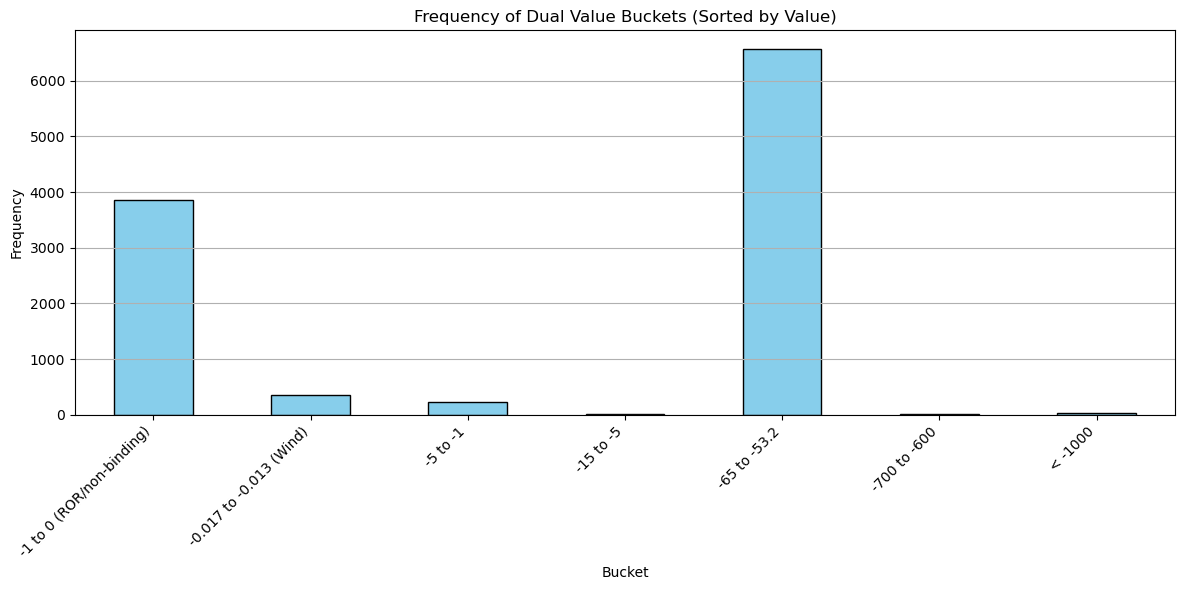

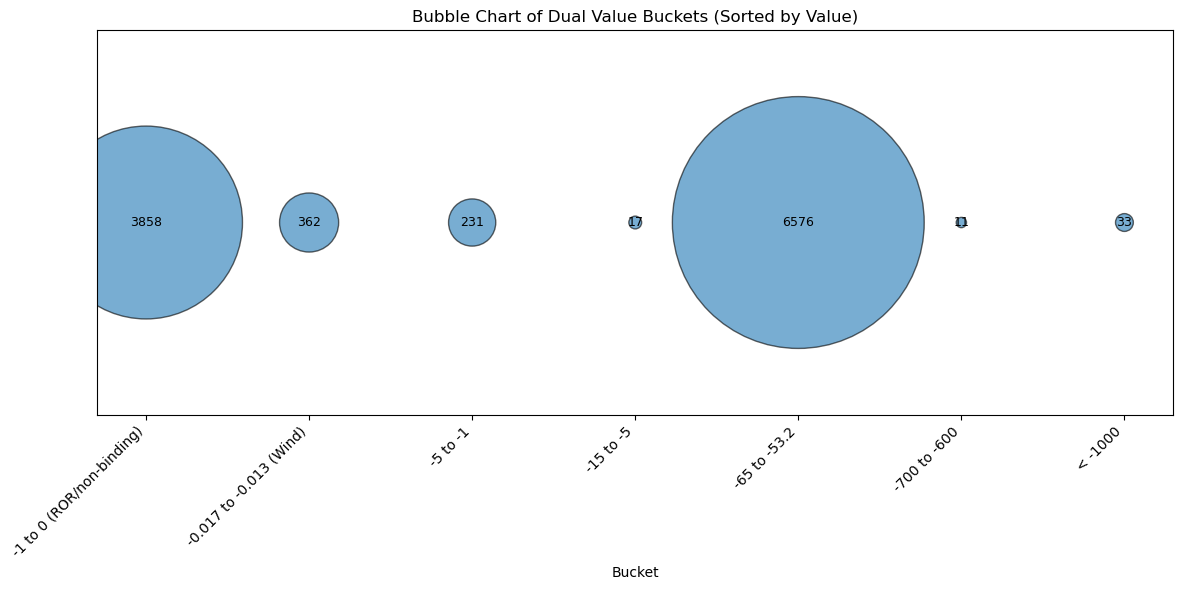

In [211]:
# Re-run necessary imports and data setup after code execution environment reset

import matplotlib.pyplot as plt
import pandas as pd


# Bucket labeling function
def label_dual_bucket(val):
    if val < -1000:
        return "< -1000"
    elif -700 <= val < -600:
        return "-700 to -600"
    elif -65 <= val <= -53.2:
        return "-65 to -53.2"
    elif -60.5 < val <= -57.5:
        return "-60.5 to -57.5 (ES CCGT)"
    elif -57.5 < val <= -56.5:
        return "-57.5 to -56.5 (ES coal)"
    elif -56.5 < val <= -54.5:
        return "-56.5 to -54.5 (PT CCGT)"
    elif -15 <= val < -5:
        return "-15 to -5"
    elif -5 <= val < -1:
        return "-5 to -1"
    elif -0.017 < val <= -0.013:
        return "-0.017 to -0.013 (Wind)"
    elif -0.013 <= val <= -0.007:
        return "-0.013 to -0.007 (Solar)"
    elif -1 <= val <= 0.001:
        return "-1 to 0 (ROR/non-binding)"
    else:
        return "Other"


# Apply buckets
dual_value_counts["bucket"] = dual_value_counts["dual_value"].apply(label_dual_bucket)

# Define numeric order for sorting
bucket_order = [
    "-1 to 0 (ROR/non-binding)",
    "-0.017 to -0.013 (Wind)",
    "-0.013 to -0.007 (Solar)",
    "-5 to -1",
    "-15 to -5",
    "-65 to -53.2",
    "-56.5 to -54.5 (PT CCGT)",
    "-57.5 to -56.5 (ES coal)",
    "-60.5 to -57.5 (ES CCGT)",
    "-700 to -600",
    "< -1000",
    "1 to 5",
    "5 to 15",
    "15 to 53",
    "Other",
]

# Group and sort
bucket_counts = (
    dual_value_counts.groupby("bucket")["frequency"]
    .sum()
    .reindex(bucket_order)
    .dropna()
)

# --- Bar Chart ---
plt.figure(figsize=(12, 6))
bucket_counts.plot(kind="bar", color="skyblue", edgecolor="black")
plt.title("Frequency of Dual Value Buckets (Sorted by Value)")
plt.ylabel("Frequency")
plt.xlabel("Bucket")
plt.xticks(rotation=45, ha="right")
plt.grid(axis="y")
plt.tight_layout()
plt.show()

# --- Bubble Chart ---
plt.figure(figsize=(12, 6))
plt.scatter(
    x=bucket_counts.index,
    y=[1] * len(bucket_counts),
    s=bucket_counts.values * 5,
    alpha=0.6,
    edgecolors="black",
)

# Annotate bubbles
for i, (label, freq) in enumerate(bucket_counts.items()):
    plt.text(label, 1, str(int(freq)), ha="center", va="center", fontsize=9)

plt.title("Bubble Chart of Dual Value Buckets (Sorted by Value)")
plt.xlabel("Bucket")
plt.yticks([])
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.grid(axis="y")
plt.show()

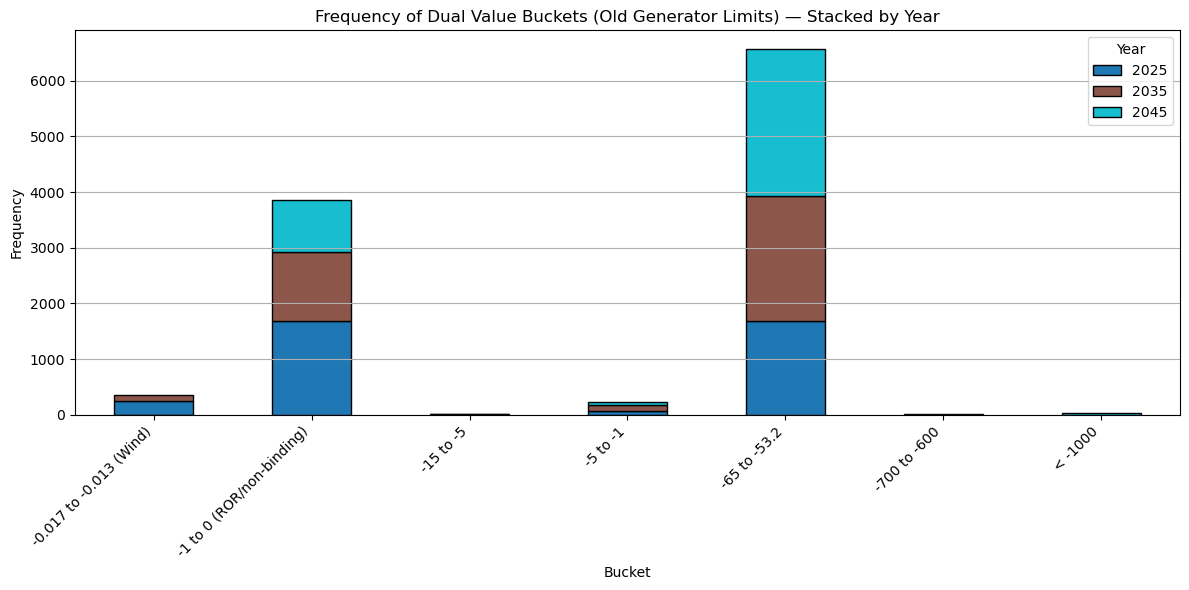

In [212]:
# Step 1: Rebuild dual_value_counts with year info
dual_value_counts_by_year = (
    gen_output_old_duals.reset_index()
    .groupby(["year", "dual_value"])
    .size()
    .reset_index(name="frequency")
)
dual_value_counts_by_year["bucket"] = dual_value_counts_by_year["dual_value"].apply(
    label_dual_bucket
)

# Step 3: Aggregate frequencies per bucket and year
bucket_counts_by_year = (
    dual_value_counts_by_year.groupby(["bucket", "year"])["frequency"]
    .sum()
    .unstack(fill_value=0)
)

# Step 5: Plot
bucket_counts_by_year.plot(
    kind="bar",
    stacked=True,
    figsize=(12, 6),
    edgecolor="black",
    colormap="tab10",
)

plt.title("Frequency of Dual Value Buckets (Old Generator Limits) — Stacked by Year")
plt.xlabel("Bucket")
plt.ylabel("Frequency")
plt.xticks(rotation=45, ha="right")
plt.grid(axis="y")
plt.tight_layout()
plt.legend(title="Year")
plt.show()

## Demand duals


In [213]:
# Prepare data
pb_duals = power_balance_duals.reset_index()
pb_duals["shadow_price"] = pb_duals["dual_value"]

# Summary stats: mean, max, and count per node
node_stats = (
    pb_duals.groupby("node")["shadow_price"]
    .agg(["mean", "max", "count"])
    .rename(columns={"count": "total_hours"})
    .sort_values("mean", ascending=False)
)

with pd.option_context("display.max_rows", None):
    print("Power balance dual stats by node:")
    print(node_stats)

Power balance dual stats by node:
            mean          max  total_hours
node                                      
ES1 0  50.233312  1106.428283         1008
PT1 0  50.230459  1107.547785         1008


In [214]:
# Filter where shadow price is above 95% of VOLL
high_pb_duals = pb_duals[
    pb_duals["shadow_price"] >= 0.3 * pb_duals["shadow_price"].max()
].copy()
high_pb_duals = high_pb_duals.sort_values(by="shadow_price", ascending=False)

print("High power balance duals (≥ 30% max dual):")
print(high_pb_duals)

High power balance duals (≥ 30% max dual):
      year  week  hour   node   dual_value  shadow_price
1937  2045    42    89  PT1 0  1107.547785   1107.547785
1938  2045    42    90  PT1 0  1107.547785   1107.547785
1939  2045    42    91  PT1 0  1107.547785   1107.547785
929   2045    42    89  ES1 0  1106.428283   1106.428283
930   2045    42    90  ES1 0  1106.428283   1106.428283
931   2045    42    91  ES1 0  1106.428283   1106.428283
1940  2045    42    92  PT1 0   686.456281    686.456281
932   2045    42    92  ES1 0   672.727155    672.727155


In [215]:
# Frequency of dual values (rounded for clarity)
pb_duals["dual_value_rounded"] = pb_duals["shadow_price"].round(3)

dual_counts = (
    pb_duals["dual_value_rounded"]
    .value_counts()
    .rename_axis("dual_value")
    .reset_index(name="frequency")
    .sort_values("dual_value")
)

print("Dual value frequencies:")
print(dual_counts)

Dual value frequencies:
    dual_value  frequency
2        0.015        362
16      13.426          1
17      13.700          1
9       53.271          4
10      54.358          4
3       54.759        277
0       55.877        596
5       57.097         69
1       57.772        463
6       58.262         29
18      58.671          1
4       58.951        184
13      59.386          2
8       60.598          6
7       62.654          7
14      63.933          2
15     672.727          1
19     686.456          1
11    1106.428          3
12    1107.548          3


<Figure size 1400x600 with 0 Axes>

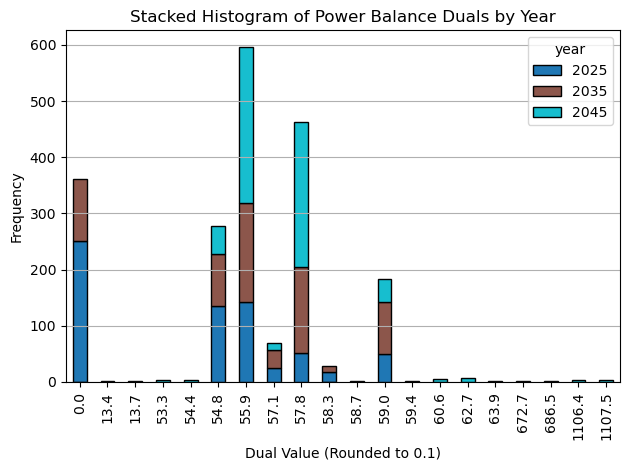

In [216]:
# Add rounded value for histogram binning
pb_duals["dual_value_bin"] = pb_duals["shadow_price"].round(1)

# Create histogram grouped by year
hist_by_year = pb_duals.groupby(["dual_value_bin", "year"]).size().unstack(fill_value=0)

# Plot
import matplotlib.pyplot as plt

plt.figure(figsize=(14, 6))
hist_by_year.plot(kind="bar", stacked=True, colormap="tab10", edgecolor="black")
plt.title("Stacked Histogram of Power Balance Duals by Year")
plt.xlabel("Dual Value (Rounded to 0.1)")
plt.ylabel("Frequency")
plt.xticks(rotation=90)
plt.grid(axis="y")
plt.tight_layout()
plt.show()

In [217]:
generators["production_cost"].loc[2025]

generator
ES1 0 CCGT          57.772380
ES1 0 coal          57.096970
ES1 0 offwind-ac     0.015000
ES1 0 onwind         0.015000
ES1 0 ror            0.000000
ES1 0 solar          0.010000
PT1 0 CCGT          55.876697
PT1 0 offwind-ac     0.015000
PT1 0 onwind         0.015000
PT1 0 ror            0.000000
PT1 0 solar          0.010000
Name: production_cost, dtype: float64

In [218]:
load_shedding.sum()

value    0.0
dtype: float64

## Calculate co2 emissions

In [219]:
# Calculate co2 emissions
generation_copy = generation.copy()
generation_copy.reset_index(inplace=True)
generators_copy = generators.copy()
generators_copy.reset_index(inplace=True)
merged = generation_copy.merge(
    generators_copy[["generator", "co2_emissions"]],
    on="generator",
    how="left",
)
merged["co2_production"] = merged["value"] * merged["co2_emissions"]
print(f"CO2 emitted: {merged["co2_production"].sum() / 1e6} Million tons")
print(f"CO2 price: {CO2_price} €/ton")
print(f"Total CO2 cost: {merged["co2_production"].sum() * CO2_price / 1e6} Million €")

CO2 emitted: 15.88657988326644 Million tons
CO2 price: 85 €/ton
Total CO2 cost: 1350.3592900776475 Million €
